# Single-cell metabolism — scMetabolism, scFEA & Compass

scRNA-seq measures **mRNA**, not metabolites — yet the transcriptome
still carries a strong, recoverable signal of a cell's metabolic
state. This tutorial walks the per-cell side of the `ov.single`
metabolism module: three complementary ways to score metabolism on
one real tumour dataset. Metabolite cell-cell communication
(MEBOCOST) has its own companion tutorial.

## Part.1 Three ways to read metabolism off a transcriptome

There is no single "right" way to infer metabolism from expression —
the field has three complementary paradigms, and `ov.single.Metabolism`
threads all three behind one `method=` switch:

**1. Pathway-activity scoring — `method='scmetabolism'`.** Score
curated KEGG / REACTOME *metabolic gene sets* per cell with an
enrichment scorer (AUCell / VISION / ssGSEA / GSVA). Fast, robust,
directly interpretable — but it reads gene *expression*, not flux.

**2. Graph-neural-network flux — `method='scfea'`.** Encode the
metabolic map as a factor graph and train a GNN to predict flux
through ~168 metabolic *modules*, minimising intermediate-metabolite
imbalance. A learned middle ground between scoring and full FBA.

**3. Constraint-based flux — `method='compass'`.** Embed expression
into a genome-scale metabolic model and solve a flux-balance linear
program for the activity of every reaction. Mechanistic and
stoichiometry-aware — but it needs a commercial LP solver and hours
of compute.

All three write the same schema — `obsm['X_metabolism']` (cells ×
metabolic features) and `uns['metabolism']` — so one plotting helper
(`ov.pl.metabolism_heatmap`) serves every backend.

In [1]:
import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Part.2 Load data — a head & neck tumour

A 200-cell head-and-neck squamous-cell-carcinoma (HNSC) demo — a
subset of the Puram et al. 2017 atlas. A tumour microenvironment
(malignant + fibroblast + endothelial + T / myeloid / plasma cells)
is the classic setting for metabolic heterogeneity: malignant cells
rewire glycolysis and oxidative phosphorylation differently from the
stroma around them.

In [2]:
adata = ov.datasets.metabolism_hnsc()
adata.obsm['X_umap'] = adata.obs[['UMAP_1', 'UMAP_2']].to_numpy()
adata

🔍 Downloading data to ./data/metabolism_hnsc_200cell.h5ad
⚠️ File ./data/metabolism_hnsc_200cell.h5ad already exists


AnnData object with n_obs × n_vars = 200 × 18241
    obs: 'UMAP_1', 'UMAP_2', 'Celltype (malignancy)', 'celltype', 'Celltype (minor-lineage)', 'Celltype (original)', 'cluster', 'Site', 'Celltype', 'Patient', 'Source', 'Age', 'Gender', 'Stage', 'TNMstage'
    obsm: 'X_umap'

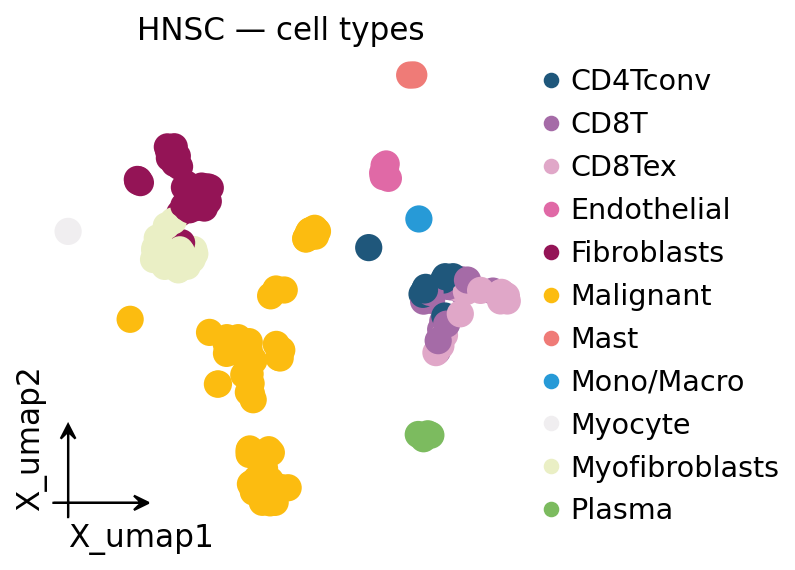

In [3]:
ov.pl.embedding(adata, basis='X_umap', color='celltype',
                frameon='small', title='HNSC — cell types')

## Part.3 scMetabolism — metabolic pathway activity

`ov.single.Metabolism(method='scmetabolism')` scores every cell
against the curated KEGG metabolic pathway collection. `score_method`
picks the enrichment scorer — `'AUCell'` (rank-based, robust to
dropouts) is a good default; `'VISION'`, `'ssGSEA'` and `'GSVA'` are
also available. Scores land in `adata.obsm['X_metabolism']` (cells ×
pathways).

In [4]:
met = ov.single.Metabolism(adata, method='scmetabolism')
met.run(score_method='AUCell', metabolism_type='KEGG')

In [5]:
# 85 KEGG metabolic pathways scored per cell
met.get(['Oxidative phosphorylation',
         'Glycolysis / Gluconeogenesis']).describe().T

,count,mean,std,min,25%,50%,75%,max
Oxidative phosphorylation,200.0,0.161400,0.074079,0.032616,0.104439,0.150236,0.208515,0.412703
Glycolysis / Gluconeogenesis,200.0,0.100547,0.040671,0.000000,0.073706,0.097932,0.130983,0.214338


A pathway × cell-type heatmap shows which lineages are metabolically
distinct — `ov.pl.metabolism_heatmap` averages the score within each
group and keeps the most variable, non-redundant pathways.

<Axes: title={'center': 'scmetabolism — metabolic features by celltype'}, xlabel='celltype'>

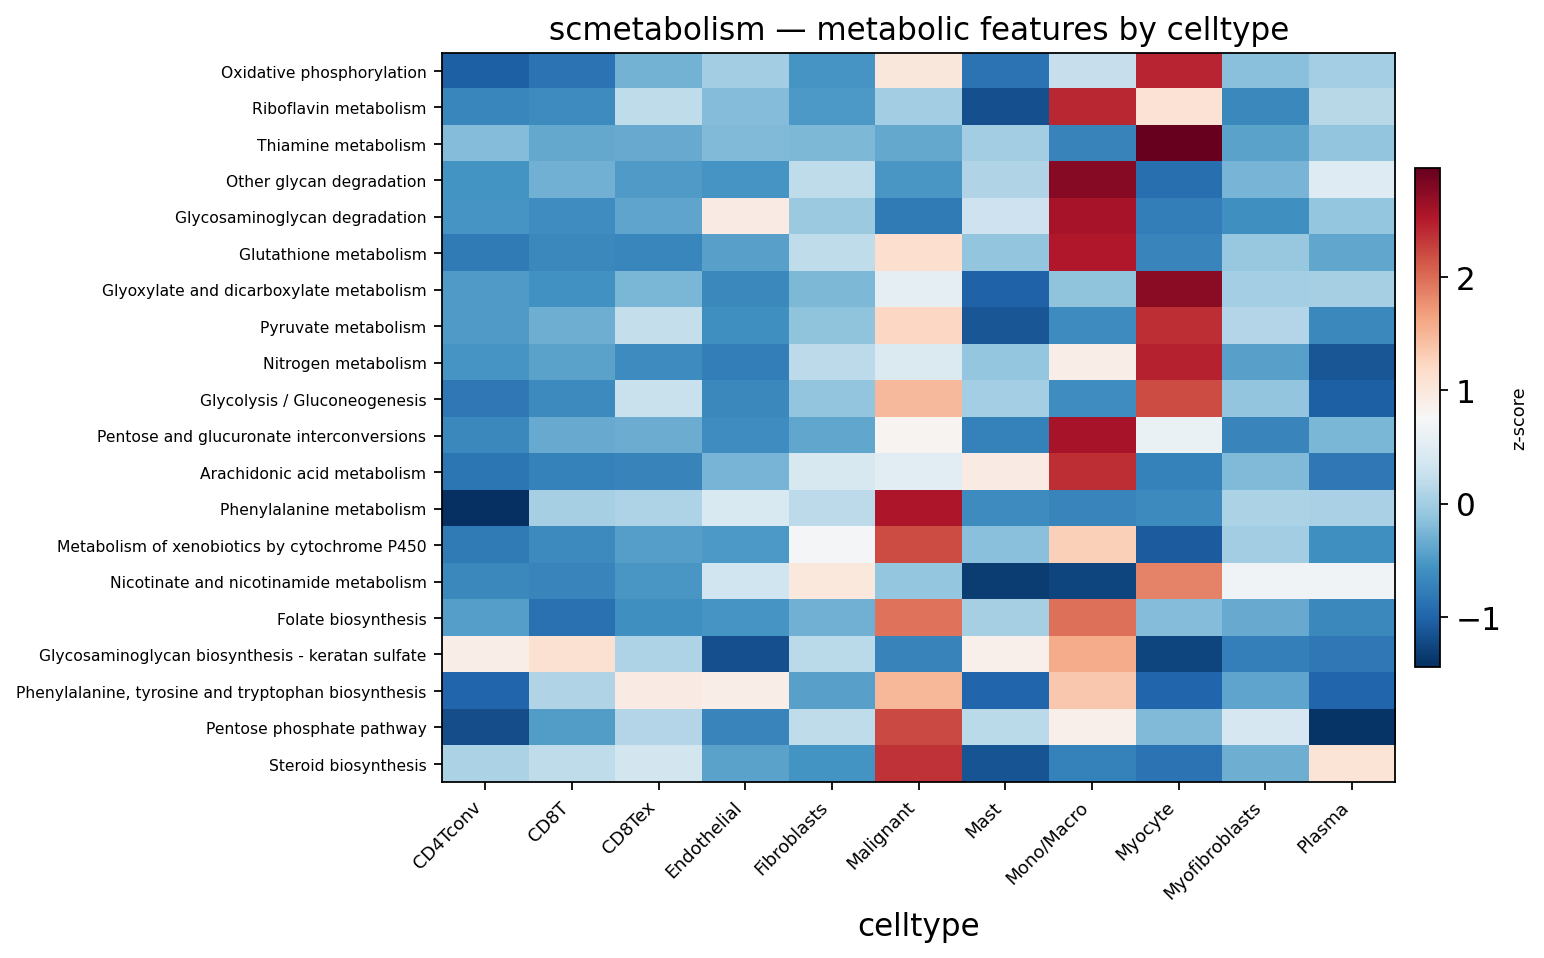

In [6]:
ov.pl.metabolism_heatmap(adata, groupby='celltype', n_features=20)

Any single pathway can be projected back onto the UMAP. Oxidative
phosphorylation typically separates the stromal / immune compartment
from the malignant cells.

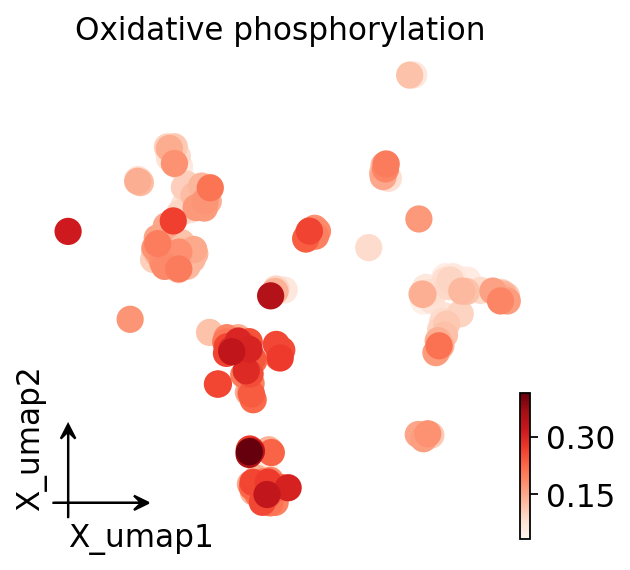

In [7]:
met.to_obs('Oxidative phosphorylation')
ov.pl.embedding(adata, basis='X_umap', color='Oxidative phosphorylation',
                cmap='Reds', frameon='small')

## Part.4 scFEA — graph-neural-network module flux

scFEA takes a different route: it encodes the metabolic network as a
factor graph (modules = reactions, factors = intermediate
metabolites) and trains a graph neural network so that predicted
flux through neighbouring modules stays mass-balanced. The result is
a per-cell flux estimate for ~168 metabolic modules — a step closer
to *flux* than a pathway score. The bundled M168 human model is used.

`n_epoch` controls GNN training — 30 here keeps the tutorial quick;
scFEA's default is 100 for a fully converged fit.

In [8]:
met_flux = ov.single.Metabolism(adata, method='scfea')
met_flux.run(n_epoch=30, verbose=False)

In [9]:
# now obsm['X_metabolism'] holds 168 module fluxes
adata.uns['metabolism']['feature_type'], adata.obsm['X_metabolism'].shape

('module_flux', (200, 168))

<Axes: title={'center': 'scfea — metabolic features by celltype'}, xlabel='celltype'>

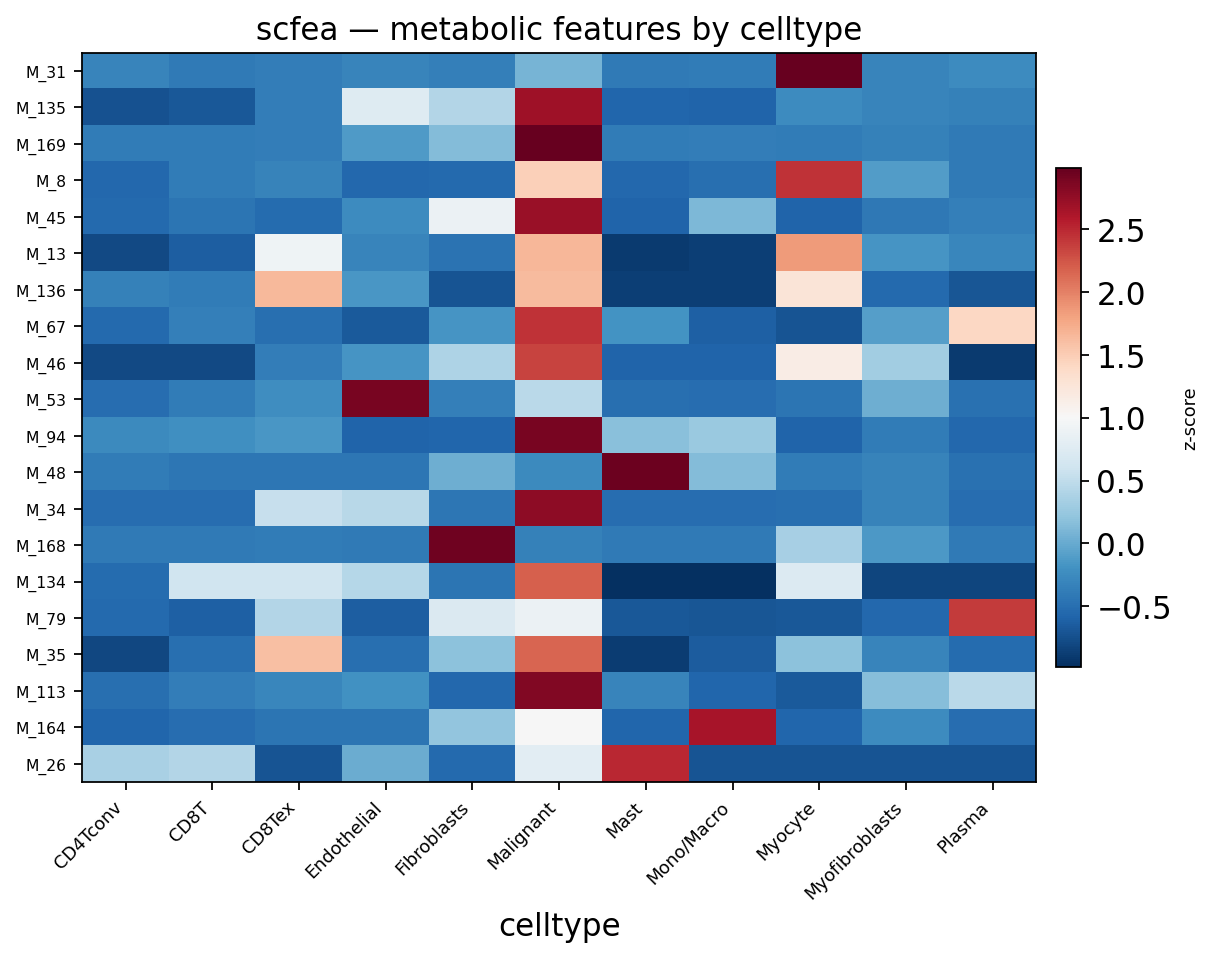

In [10]:
ov.pl.metabolism_heatmap(adata, groupby='celltype', n_features=20)

## Part.5 Compass — constraint-based reaction flux

Compass is the most mechanistic of the three: it embeds each cell's
expression into a genome-scale metabolic model (RECON2) and solves a
flux-balance linear program for the activity of **every reaction**.
That power has a price — Compass needs a commercial LP solver (IBM
CPLEX or Gurobi) and runs for hours, so it is a CLI tool you run
offline. `ov.single.Metabolism(method='compass')` therefore **loads a
precomputed Compass run** and maps it onto the AnnData. Here the
Compass output was computed per cell type, so `group_key='celltype'`
broadcasts each group's reaction-flux profile to its cells. Reactions
in a linear pathway are *flux-coupled* (they carry identical flux), so
`metabolism_heatmap` drops near-duplicate reactions to stay readable.

In [11]:
compass_dir = ov.datasets.metabolism_compass()
met_cps = ov.single.Metabolism(adata, method='compass')
met_cps.run(compass_dir=compass_dir, group_key='celltype')

🔍 Downloading data to ./data/compass_hnsc.zip
⚠️ File ./data/compass_hnsc.zip already exists


In [12]:
# 10,211 RECON2 reactions; 'level' records the broadcast
adata.uns['metabolism']['level'], adata.obsm['X_metabolism'].shape

('group', (200, 10211))

<Axes: title={'center': 'compass — metabolic features by celltype'}, xlabel='celltype'>

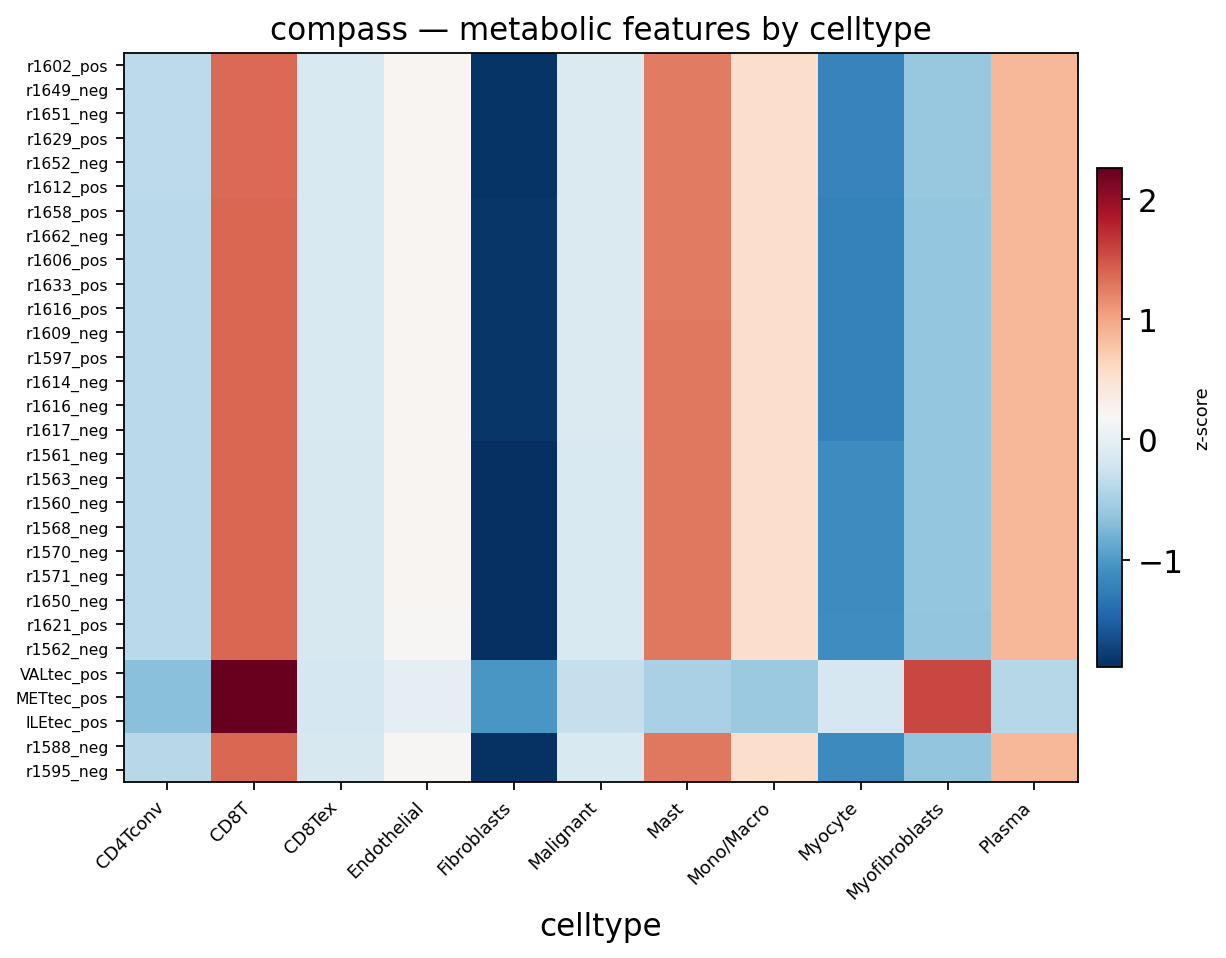

In [13]:
# decorrelate=False: Compass reactions are flux-coupled, so show the
# dense flux landscape rather than dropping the coupled set.
ov.pl.metabolism_heatmap(adata, groupby='celltype',
                         n_features=30, decorrelate=False)

---

**Recap.** One AnnData, three views of per-cell metabolism:

| call | output | reads |
|---|---|---|
| `Metabolism(method='scmetabolism')` | pathway activity | curated gene sets |
| `Metabolism(method='scfea')` | module flux | GNN on the metabolic map |
| `Metabolism(method='compass')` | reaction flux | genome-scale FBA (precomputed) |

Pathway scoring is the fast first pass; scFEA and Compass add
flux-level detail at rising compute cost. To lift the analysis from
single-cell metabolism to the metabolic *ecology* of the tissue — which
cell types exchange which metabolites — see the companion tutorial
**Metabolite cell-cell communication with MEBOCOST**.